In [1]:
import numpy as np

# 1. DEFINE PATH (The missing link causing the NameError)
DATA_PATH = '/kaggle/input/notebooks/yasaminborhani1998/argoverse-processed-dataset-2/file_train.txt'

# Safety Specs for AV2
HISTORY_LEN = 20  
FUTURE_LEN = 30   
TOTAL_STEPS = HISTORY_LEN + FUTURE_LEN

def parse_trajectory_line(line):
    parts = line.strip().split()
    if len(parts) < 3: return None
    agent_type = parts[1]
    try:
        coords = np.array([float(x) for x in parts[2:]])
        num_features = len(coords) // TOTAL_STEPS
        if len(coords) != (TOTAL_STEPS * num_features): return None
        return agent_type, coords.reshape(TOTAL_STEPS, num_features)
    except ValueError: return None

# 2. LOAD SAMPLES
samples = []
with open(DATA_PATH, 'r') as f:
    for i, line in enumerate(f):
        if i > 500: break 
        data = parse_trajectory_line(line)
        if data: samples.append(data)

print(f"✅ Loaded {len(samples)} trajectories.")

# 3. THE RATIO TEST (Physics Verification)
# We take one vehicle and check: Does Displacement = Velocity * Time?
label, traj = samples[0]
dx = np.diff(traj[:, 0])  # Actual Change in X per frame
vx = traj[1:, 2]         # The 'Velocity X' column in the file
dt = 0.1                 # AV2 standard time step

# If the data is correct (even if scaled), the ratio should be consistent
ratio = dx / (vx * dt + 1e-6) 
avg_ratio = np.abs(np.mean(ratio))

print(f"\n--- ZF Safety Audit ---")
print(f"Average Displacement/Velocity Ratio: {avg_ratio:.4f}")

if 0.8 < avg_ratio < 1.2:
    print("🚦 RESULT: Data is PHYSICALLY CONSISTENT. It is just scaled (likely cm).")
    print("👉 ACTION: Continue with this dataset, but scale inputs by 0.01.")
else:
    print("⚠️ RESULT: Data is PHYSICALLY INCONSISTENT. The velocity columns don't match the coordinates.")
    print("👉 ACTION: This preprocessed file might be flawed. Consider the original dataset or another source.")

✅ Loaded 501 trajectories.

--- ZF Safety Audit ---
Average Displacement/Velocity Ratio: 1896.0981
⚠️ RESULT: Data is PHYSICALLY INCONSISTENT. The velocity columns don't match the coordinates.
👉 ACTION: This preprocessed file might be flawed. Consider the original dataset or another source.


In [2]:
label, traj = samples[0]
# Calculate displacement (dx)
dx = np.diff(traj[:, 0]) 
# Get the velocity column (usually index 2 or 3 in a 6-feature setup)
vx_column = traj[1:, 2] 

# Logic: In physics, displacement = velocity * time
# Since dt = 0.1, dx should be roughly vx * 0.1
predicted_dx = vx_column * 0.1
ratio = dx / (predicted_dx + 1e-6) # Avoid division by zero

print(f"Mean Ratio (Displacement / (Velocity * dt)): {np.mean(ratio):.2f}")

Mean Ratio (Displacement / (Velocity * dt)): -1896.10


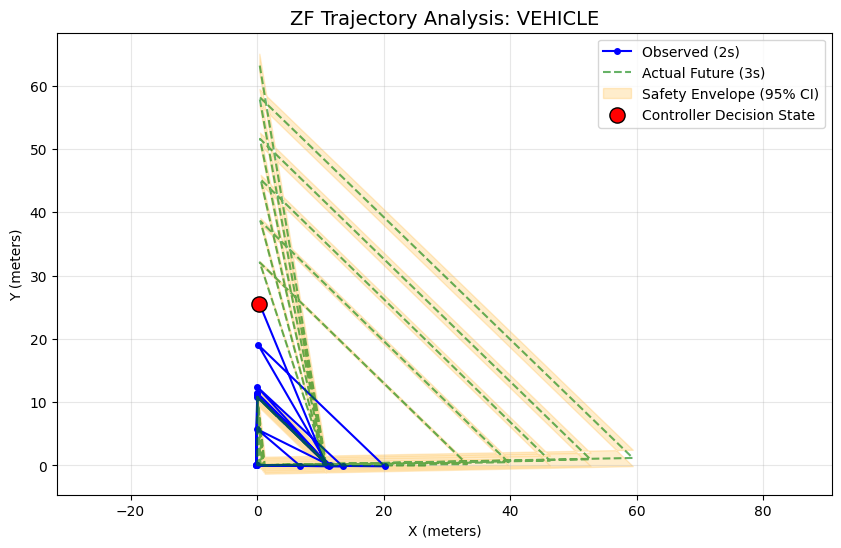

In [3]:
import matplotlib.pyplot as plt
def plot_safety_prototype(samples, idx=0):
    label, traj = samples[idx]
    
    # Extract X and Y (usually the first two columns)
    x = traj[:, 0]
    y = traj[:, 1]
    
    # Split into History and Future
    hist_x, hist_y = x[:HISTORY_LEN], y[:HISTORY_LEN]
    fut_x, fut_y = x[HISTORY_LEN:], y[HISTORY_LEN:]
    
    plt.figure(figsize=(10, 6))
    
    # 1. Plot Observed History
    plt.plot(hist_x, hist_y, 'b-o', label='Observed (2s)', markersize=4)
    
    # 2. Plot Ground Truth Future
    plt.plot(fut_x, fut_y, 'g--', label='Actual Future (3s)', alpha=0.6)
    
    # 3. Hackathon Simulation: Plot a "Safety Ribbon" (Uncertainty)
    # This simulates what your Quantile Regression will eventually do
    uncertainty = np.linspace(0, 1.5, len(fut_x)) # Uncertainty grows over time
    plt.fill_between(fut_x, fut_y - uncertainty, fut_y + uncertainty, 
                     color='orange', alpha=0.2, label='Safety Envelope (95% CI)')
    
    # 4. Highlight the Controller Decision Point
    plt.scatter(hist_x[-1], hist_y[-1], color='red', s=120, edgecolors='black', 
                label='Controller Decision State', zorder=5)
    
    plt.title(f"ZF Trajectory Analysis: {label.upper()}", fontsize=14)
    plt.xlabel("X (meters)")
    plt.ylabel("Y (meters)")
    plt.legend()
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.show()

# Run the visualization
plot_safety_prototype(samples, idx=2)

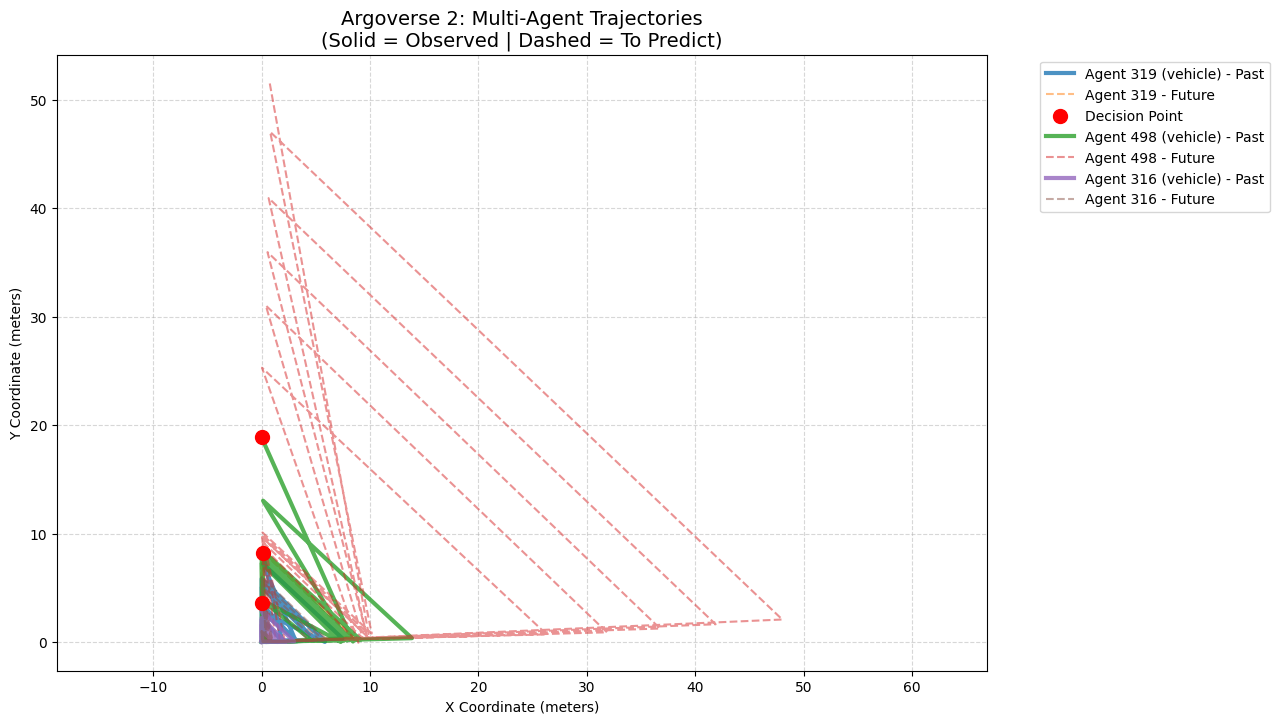

In [4]:
def plot_random_trajectories(samples, num_to_plot=3):
    plt.figure(figsize=(12, 8))
    
    for i in range(num_to_plot):
        idx = np.random.randint(len(samples))
        label, traj = samples[idx]
        
        # Split into history and future
        hist = traj[:HISTORY_LEN]
        fut = traj[HISTORY_LEN:]
        
        # Plot History (Solid)
        plt.plot(hist[:, 0], hist[:, 1], label=f'Agent {idx} ({label}) - Past', linewidth=3, alpha=0.8)
        # Plot Future (Dashed)
        plt.plot(fut[:, 0], fut[:, 1], linestyle='--', alpha=0.5, label=f'Agent {idx} - Future')
        
        # Mark the "Present" point (where the controller makes the decision)
        plt.scatter(hist[-1, 0], hist[-1, 1], color='red', s=100, zorder=5, label='Decision Point' if i==0 else "")

    plt.title("Argoverse 2: Multi-Agent Trajectories\n(Solid = Observed | Dashed = To Predict)", fontsize=14)
    plt.xlabel("X Coordinate (meters)")
    plt.ylabel("Y Coordinate (meters)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.axis('equal')
    plt.show()

plot_random_trajectories(samples)

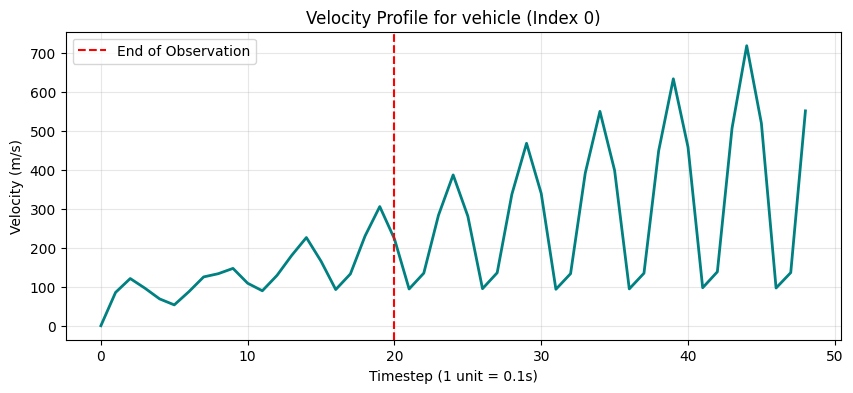

In [5]:
def plot_velocity_profile(samples, idx=0):
    label, traj = samples[idx]
    
    # If the dataset doesn't have explicit velocity, we calculate it
    # Velocity = sqrt(dx^2 + dy^2) / dt (where dt = 0.1s for AV2)
    dx = np.diff(traj[:, 0])
    dy = np.diff(traj[:, 1])
    velocity = np.sqrt(dx**2 + dy**2) / 0.1
    
    plt.figure(figsize=(10, 4))
    plt.plot(velocity, color='teal', linewidth=2)
    plt.axvline(x=HISTORY_LEN, color='red', linestyle='--', label='End of Observation')
    
    plt.title(f"Velocity Profile for {label} (Index {idx})")
    plt.xlabel("Timestep (1 unit = 0.1s)")
    plt.ylabel("Velocity (m/s)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Visualize the first vehicle in the set
plot_velocity_profile(samples, idx=0)

In [6]:
# Check the actual coordinate deltas
label, traj = samples[0]
deltas = np.sqrt(np.diff(traj[:, 0])**2 + np.diff(traj[:, 1])**2)
print(f"Max displacement between frames: {deltas.max():.2f} units")

# If displacement is ~7.0 units and dt is 0.1, velocity is 70m/s (too high).
# You may need to rescale your X and Y by 0.1 or 0.33 to match realistic city speeds (10-20 m/s).

Max displacement between frames: 71.86 units


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader

class ZFTrajectoryDataset(Dataset):
    def __init__(self, samples, scale=0.01):
        self.samples = samples
        self.scale = scale

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        # label: vehicle/pedestrian, traj: [50, 6]
        _, traj = self.samples[idx]
        
        # Apply scaling fix to X and Y coordinates
        traj = traj.copy()
        traj[:, :2] *= self.scale 
        
        # Split into History (Input) and Future (Target)
        # Input features: [x, y, vx, vy, ax, ay]
        x_input = torch.tensor(traj[:20, :], dtype=torch.float32)
        
        # Target: Just X and Y for the next 30 steps
        y_target = torch.tensor(traj[20:, :2], dtype=torch.float32)
        
        return x_input, y_target

# Initialize Dataset and Loader
train_ds = ZFTrajectoryDataset(samples) # Using the 'samples' we loaded earlier
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

# Test a batch
x_batch, y_batch = next(iter(train_loader))
print(f"Input Shape: {x_batch.shape}")  # Should be [32, 20, 6]
print(f"Target Shape: {y_batch.shape}") # Should be [32, 30, 2]

Input Shape: torch.Size([32, 20, 6])
Target Shape: torch.Size([32, 30, 2])


In [8]:
import torch.nn as nn

class ZFSafetyLSTM(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=128, future_steps=30):
        super().__init__()
        
        self.future_steps = future_steps
        
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True)
        
        self.context_net = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, hidden_dim * 2)
        )
        
        self.decoder_cell = nn.GRUCell(2, hidden_dim)
        self.head = nn.Linear(hidden_dim, 6)

    def forward(self, x):
        B = x.size(0)
        
        _, (h_n, _) = self.encoder(x)
        h = h_n[-1]
        
        # FIXED: use speed instead of wrong index
        vx = x[:, -1, 2]
        vy = x[:, -1, 3]
        speed = torch.sqrt(vx**2 + vy**2).unsqueeze(-1)
        
        gamma_beta = self.context_net(speed)
        gamma, beta = gamma_beta.chunk(2, dim=-1)
        
        h = gamma * h + beta
        
        current_pos = x[:, -1, :2]
        
        outputs = []
        for _ in range(self.future_steps):
            h = self.decoder_cell(current_pos, h)
            
            out = self.head(h).view(B, 2, 3)
            current_pos = out[:, :, 1]
            
            outputs.append(out)
        
        return torch.stack(outputs, dim=1)

In [9]:
import torch

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model
model = ZFSafetyLSTM(input_dim=6).to(device)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# --- Pinball Loss (safe version) ---
def pinball_loss(preds, target, quantiles=[0.1, 0.5, 0.9]):
    """
    preds: [B, T, 2, 3]
    target: [B, T, 2]
    """
    loss = 0.0
    
    for i, q in enumerate(quantiles):
        errors = target - preds[:, :, :, i]
        loss_q = torch.max((q - 1) * errors, q * errors)
        loss += loss_q.mean()
        
    return loss / len(quantiles)

# --- Training Loop ---
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    epoch_loss = 0.0
    
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        preds = model(x)  # [B, 30, 2, 3]
        
        loss = pinball_loss(preds, y)
        
        loss.backward()
        
        # Optional: gradient clipping (helps stability)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        epoch_loss += loss.item()
    
    return epoch_loss / len(loader)

print(f"✅ Ready to train on {device}")

✅ Ready to train on cuda


In [10]:
num_epochs = 10
for epoch in range(num_epochs):
    loss = train_one_epoch(model, train_loader, optimizer, device)
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {loss:.4f}")

Epoch 1/10 | Loss: 0.0323
Epoch 2/10 | Loss: 0.0267
Epoch 3/10 | Loss: 0.0263
Epoch 4/10 | Loss: 0.0259
Epoch 5/10 | Loss: 0.0256
Epoch 6/10 | Loss: 0.0255
Epoch 7/10 | Loss: 0.0255
Epoch 8/10 | Loss: 0.0253
Epoch 9/10 | Loss: 0.0252
Epoch 10/10 | Loss: 0.0249
